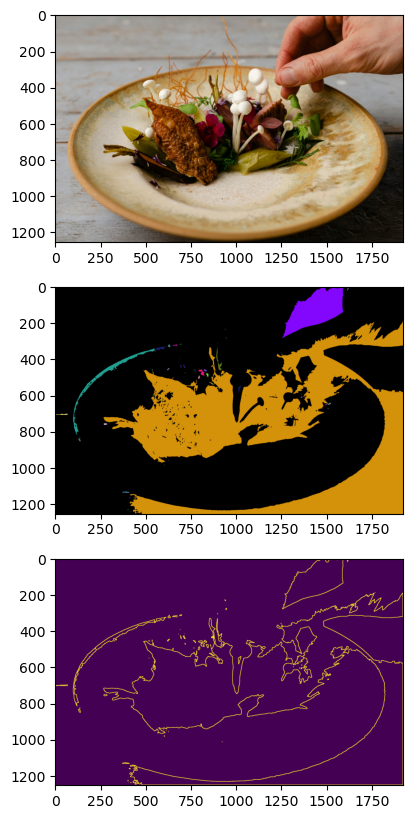

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("imagen-1.jpg")
imgrgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray,(7,7),0)
_,binarizado = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

#regiones
cant,region = cv2.connectedComponents(binarizado)
colores = np.random.randint(0,255,size=(cant,3),dtype=np.uint8)
colores[0] = [0,0,0]
color_regionb = colores[region]

#fronteras
contorno,_ = cv2.findContours(binarizado, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lineas = cv2.drawContours(np.zeros_like(gray),contorno,-1,255,2)

figure,axs = plt.subplots(3,1,figsize=(10,10))
axs[0].imshow(imgrgb)
axs[1].imshow(color_regionb)
axs[2].imshow(lineas)


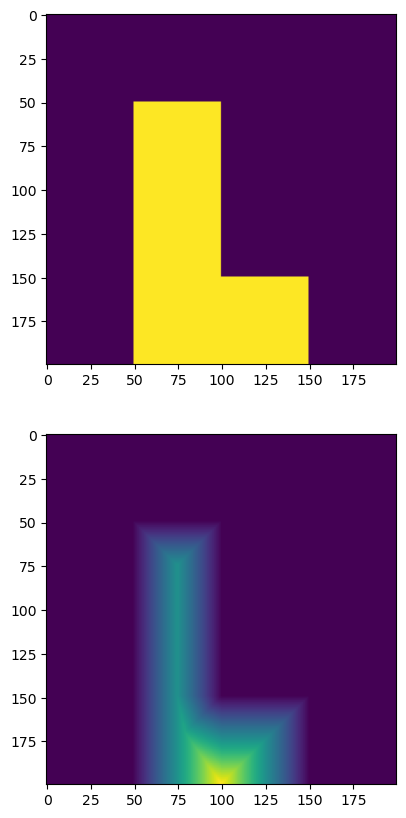

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((200,200),dtype=np.uint8)
img[50:150,50:100]=1
img[150:200,50:150]=1
def distancia(img_binarizada):
    invertir = 1-img_binarizada
    #euclidiana
    dist_eucli = cv2.distanceTransform(img_binarizada, cv2.DIST_L2, 3)
    # city block
    dist_city = cv2.distanceTransform(img_binarizada, cv2.DIST_L1, 3)
    #chessborard
    dist_chess = cv2.distanceTransform(img_binarizada, cv2.DIST_C, 3)

    return ( dist_eucli, dist_city, dist_chess)

eu,ci,ch = distancia(img)

figure,axs = plt.subplots(2,1,figsize=(10,10))
axs[0].imshow(img)
axs[1].imshow(eu)

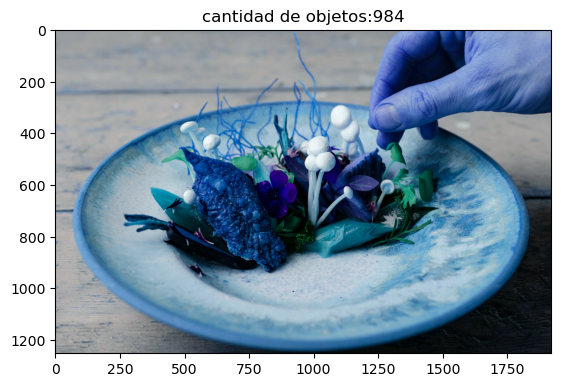

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(imagen):
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    _,binarizar = cv2.threshold(gray, 127,255,cv2.THRESH_BINARY)
    # Conectividad de 4 es 2. 
    # Conectividad de 8 es 1. 
    etiquetar = measure.label(binarizar, connectivity=2) 
    num = np.max(etiquetar)
    return num
img = cv2.imread("imagen-1.jpg")
contarr = contar(img)
plt.imshow(img)
plt.title(f'cantidad de objetos:{contarr}')
plt.show()
